# Mental Health

**Mục tiêu:** Dự đoán nguy cơ mắc bệnh trầm cảm (Depression) dựa trên thông tin nhân khẩu học, áp lực công việc/học tập và thói quen sinh hoạt.

## Import Library

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pyampute.exploration.mcar_statistical_tests import MCARTest

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer
from sklearn.impute import SimpleImputer
from scipy.stats import zscore, ks_2samp, levene
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
import itertools
import gc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold
from collections import Counter

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

TRAIN_DATA_PATH = '../data/raw/train.csv'
TEST_DATA_PATH = '../data/raw/test.csv'
PROCESSED_TRAIN_PATH = '../data/processed/train.csv'
PROCESSED_VALID_PATH = '../data/processed/valid.csv'
PROCESSED_TEST_PATH = '../data/processed/test.csv'


## 1. Data Exploration


### 1.1. Tổng quan Dữ liệu

Tập dữ liệu này thu thập thông tin về tình trạng sức khỏe tinh thần (đặc biệt là Trầm cảm - Depression) của hai nhóm đối tượng chính: **Sinh viên (Student)** và **Người đi làm (Working Professional)**. Dưới đây là ý nghĩa chi tiết của từng đặc trưng (feature) trong dữ liệu:

#### 1. Thông tin cá nhân cơ bản
* **`id`**: Số định danh duy nhất cho mỗi cá nhân tham gia khảo sát.
* **`Name`**: Tên của người tham gia.
* **`Gender`**: Giới tính (Nam, Nữ, v.v.).
* **`Age`**: Tuổi của người tham gia.
* **`City`**: Thành phố nơi người tham gia đang sinh sống, học tập hoặc làm việc.

#### 2. Thông tin Học vấn & Nghề nghiệp
* **`Working Professional or Student`**: Phân loại đối tượng tham gia là Sinh viên hay Người đi làm.
* **`Profession`**: Nghề nghiệp hiện tại (Chỉ áp dụng cho Người đi làm, đối với Sinh viên cột này thường rỗng).
* **`Degree`**: Bằng cấp đang theo học (với sinh viên) hoặc đã đạt được (với người đi làm) (VD: B.Pharm, BBA, BHM...).

#### 3. Áp lực & Mức độ hài lòng
* **`Academic Pressure`**: Thang điểm đánh giá mức độ áp lực học tập (Chủ yếu dành cho sinh viên).
* **`Work Pressure`**: Thang điểm đánh giá mức độ áp lực công việc (Chủ yếu dành cho người đi làm).
* **`CGPA`**: Điểm trung bình tích lũy (Chỉ số học lực liên tục, dành cho sinh viên).
* **`Study Satisfaction`**: Thang điểm đánh giá mức độ hài lòng với việc học và môi trường giáo dục.
* **`Job Satisfaction`**: Thang điểm đánh giá mức độ hài lòng với công việc hiện tại.
* **`Work/Study Hours`**: Tổng số giờ dành cho việc học hoặc làm việc mỗi ngày.
* **`Financial Stress`**: Thang điểm đánh giá mức độ căng thẳng, áp lực về vấn đề tài chính.

#### 4. Thói quen sinh hoạt & Yếu tố nguy cơ
* **`Sleep Duration`**: Thời lượng giấc ngủ trung bình mỗi ngày (Biến phân loại: *Less than 5 hours, 5-6 hours, More than 8 hours...*).
* **`Dietary Habits`**: Đánh giá thói quen ăn uống (Biến phân loại: *Healthy, Unhealthy, Moderate*).
* **`Family History of Mental Illness`**: Tiền sử mắc bệnh tâm lý/tâm thần trong gia đình (Yes / No).
* **`Have you ever had suicidal thoughts ?`**: Người tham gia từng có suy nghĩ tự tử hay chưa (Yes / No).

#### 5. Biến mục tiêu
* **`Depression`**: Tình trạng trầm cảm của người tham gia. Được mã hóa dưới dạng nhị phân (**1** = Có bị trầm cảm, **0** = Không bị trầm cảm). Đây là biến dự đoán (label) chính cho các bài toán phân loại (Classification).

In [67]:
train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)
# Cast target column to category
train_df['Depression'] = train_df['Depression'].astype('category')

# train_df.drop(['id', 'Name'], axis=1, inplace=True, errors='ignore')
# test_df.drop(['id', 'Name'], axis=1, inplace=True, errors='ignore')

display(train_df.head())
print("Kích thước dữ liệu:", train_df.shape)
train_df.info()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


Kích thước dữ liệu: (140700, 20)
<class 'pandas.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype   
---  ------                                 --------------   -----   
 0   id                                     140700 non-null  int64   
 1   Name                                   140700 non-null  str     
 2   Gender                                 140700 non-null  str     
 3   Age                                    140700 non-null  float64 
 4   City                                   140700 non-null  str     
 5   Working Professional or Student        140700 non-null  str     
 6   Profession                             104070 non-null  str     
 7   Academic Pressure                      27897 non-null   float64 
 8   Work Pressure                          112782 non-null  float64 
 9   CGPA                                   27898 non-null   float64 
 10  Study Satisfaction    

In [68]:
display(train_df.describe())
display(train_df.describe(include=['object', 'category']))

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000


,Name,Gender,City,Working Professional or Student,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness,Depression
count,140700,140700,140700,140700,104070,140700,140696,140698,140700,140700,140700
unique,422,2,98,2,64,36,23,115,2,2,2
top,Rohan,Male,Kalyan,Working Professional,Teacher,Less than 5 hours,Moderate,Class 12,No,No,0
freq,3178,77464,6591,112799,24906,38784,49705,14729,71138,70758,115133


#### Đánh giá Sơ lược Dữ liệu (Data Understanding & Key Observations)

Sau khi kiểm tra thông tin tổng quan (`info`) và thống kê mô tả (`describe`), chúng ta có thể rút ra các nhận định quan trọng sau để định hướng cho bước Tiền xử lý (Preprocessing):

**1. Tổng quan Kích thước & Cấu trúc**
* Tập dữ liệu có **140,700 dòng** và **19 cột** (bao gồm 1 biến mục tiêu `Depression` và 18 biến đặc trưng).
* Dữ liệu bao gồm nhiều kiểu khác nhau: 8 cột số thực (`float64`), 1 cột số nguyên (`int64`), và 10 cột phân loại dạng chuỗi (`object`).


**2. Vấn đề "Rác" dữ liệu & Tính nhất quán (Data Inconsistency)**
Qua bảng thống kê biến phân loại (Categorical), tập dữ liệu đang gặp vấn đề nghiêm trọng về chuẩn hóa định dạng (text formatting):
* `Sleep Duration` có tới **36** giá trị unique (Lẽ ra chỉ nên có khoảng 4-5 nhóm thời lượng).
* `Dietary Habits` có **23** giá trị unique.
* `Degree` có tận **115** giá trị unique.
* Đây là dấu hiệu rõ ràng của việc nhập liệu tự do (typo, viết tắt, khác biệt khoảng trắng). Cần được gom nhóm (Mapping) và làm sạch các chuỗi này, quá trình Encoding phía sau sẽ tạo ra hàng trăm cột rác (Curse of Dimensionality).

**3. Các thang đo Ordinal**
* Các biến áp lực và hài lòng (`Academic Pressure`, `Work Pressure`, v.v.) hiện mang kiểu `float64` với giới hạn từ 1.0 đến 5.0. Thực chất, đây là các biến phân loại có thứ bậc (Ordinal). Ta có thể cân nhắc giữ nguyên dưới dạng số học hoặc ép kiểu về Category tùy thuộc vào thuật toán học máy được chọn.

Trước khi đi vào phân tích, ta sẽ loại bỏ Cột `Name` vì đây là biến định danh, có 422 giá trị unique lặp lại. Biến này không mang ý nghĩa dự đoán về mặt thống kê và có nguy cơ gây nhiễu (overfitting) nên sẽ cần được loại bỏ.

In [69]:
train_df = train_df.drop(columns=['Name'])
test_df = test_df.drop(columns=['Name'])

### 1.2. Phân tích Đơn biến (Univariate Analysis)
Khám phá phân phối của biến mục tiêu `Depression` và các đặc trưng quan trọng khác.

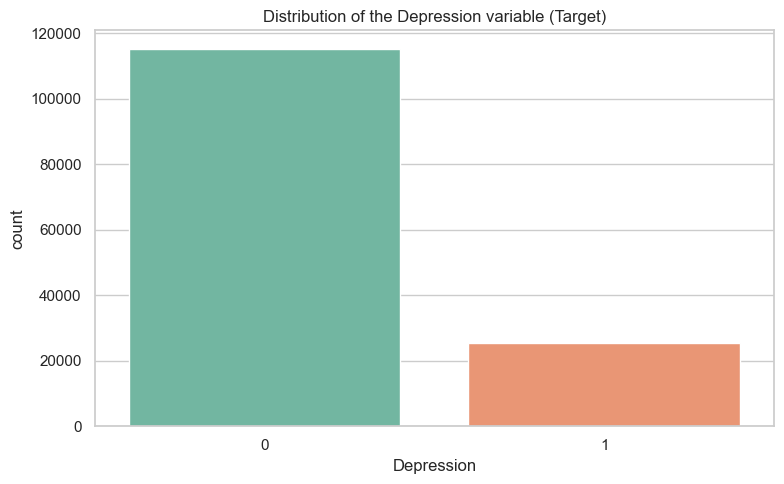

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(x='Depression', data=train_df, ax=ax, palette='Set2')
ax.set_title('Distribution of the Depression variable (Target)')

plt.tight_layout()
plt.show()

* Giá trị trung bình (`mean`) của biến mục tiêu `Depression` là **0.1817**. Điều này đồng nghĩa chỉ có khoảng **18.17%** số người trong tập dữ liệu mắc trầm cảm. Đây là một bài toán mất cân bằng dữ liệu y tế điển hình, đòi hỏi mô hình phải được đo lường bằng F1-Score, ROC-AUC thay vì Accuracy, và có thể cần áp dụng thêm kỹ thuật xử lý mất cân bằng dữ liệu.

In [ ]:
num_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Work/Study Hours', 'Financial Stress', 'Study Satisfaction',  'Job Satisfaction']

fig, axes = plt.subplots(3, 3, figsize=(18, 10))

for i, col in enumerate(num_cols):
    ax = axes[i//3, i%3]

    # 'CGPA' is the only truly continuous variable
    if col == 'CGPA':
        sns.histplot(train_df[col], kde=True, ax=ax)
    else:
        # Discrete variables: disable KDE and force bins to discrete values
        sns.histplot(train_df[col], kde=False, discrete=True, ax=ax)

    ax.set_title(f'Distribution of {col}')

fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()

In [ ]:
# List of basic categorical variables
cat_cols = ['Gender', 'Have you ever had suicidal thoughts ?',
            'Family History of Mental Illness', 'Dietary Habits']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cat_cols):
    sns.countplot(data=train_df, x=col, ax=axes[i//2, i%2], palette='pastel',
                  order=train_df[col].value_counts().index) # Sort columns from highest to lowest

    axes[i//2, i%2].set_title(f'Distribution of {col}')
    axes[i//2, i%2].tick_params(axis='x', rotation=45) # Rotate X-axis labels to avoid overlap

plt.tight_layout()
plt.show()

In [ ]:
# Function to plot Top N most frequent values for columns with many unique values
def plot_top_categories(dataframe, column, top_n=10):
    plt.figure(figsize=(10, 6))

    # Get the Top N most frequent values
    top_values = dataframe[column].value_counts().nlargest(top_n)

    # Plot horizontal bar chart
    sns.barplot(x=top_values.values, y=top_values.index, palette='viridis')

    plt.title(f'Top {top_n} most frequent values of {column}')
    plt.xlabel('Count')
    plt.ylabel(column)
    plt.show()

plot_top_categories(train_df, 'Degree', top_n=30)
plot_top_categories(train_df, 'Profession', top_n=15)
plot_top_categories(train_df, 'City', top_n=15)
plot_top_categories(train_df, 'Sleep Duration', top_n=10)

### 1.3. Phân tích Đa biến & Tương quan
Xem xét mối liên hệ giữa các đặc trưng với biến mục tiêu (Ví dụ: Áp lực tài chính có dẫn đến trầm cảm cao hơn không?)

In [ ]:
# cast type to have a correlation of other feature with Depression
train_df['Depression'] = train_df['Depression'].astype('int64')
# select numeric columns only (avoid wrongly encoded categorical features)
numeric_train_df = train_df.select_dtypes(include=['float64', 'int64'])

# compute correlation matrices
pearson_corr = numeric_train_df.corr(method='pearson')
spearman_corr = numeric_train_df.corr(method='spearman')

# plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pearson - linear correlation
sns.heatmap(
    pearson_corr, annot=True, cmap='coolwarm', fmt=".2f",
    linewidths=0.5, ax=axes[0], vmin=-1, vmax=1
)
axes[0].set_title('Pearson Correlation Matrix (Linear)', fontsize=14, pad=15)

# Spearman - rank / monotonic correlation
sns.heatmap(
    spearman_corr, annot=True, cmap='coolwarm', fmt=".2f",
    linewidths=0.5, ax=axes[1], vmin=-1, vmax=1
)
axes[1].set_title('Spearman Correlation Matrix (Rank-based)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

# find highly correlated pairs (|r| > threshold)
def get_highly_correlated_pairs(corr_matrix, threshold=0.9):
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    high_corr = []
    for col in upper_tri.columns:
        for row in upper_tri.index:
            if abs(upper_tri.loc[row, col]) > threshold:
                high_corr.append((row, col, upper_tri.loc[row, col]))
    return high_corr

print("--- HIGH MULTICOLLINEARITY CHECK (|r| > 0.9) ---")

print("\nPearson:")
pearson_pairs = get_highly_correlated_pairs(pearson_corr)
if not pearson_pairs:
    print("- No pairs with Pearson correlation > 0.9")
else:
    for pair in pearson_pairs:
        print(f"- {pair[0]} and {pair[1]}: r = {pair[2]:.4f}")

print("\nSpearman:")
spearman_pairs = get_highly_correlated_pairs(spearman_corr)
if not spearman_pairs:
    print("- No pairs with Spearman correlation > 0.9")
else:
    for pair in spearman_pairs:
        print(f"- {pair[0]} and {pair[1]}: r = {pair[2]:.4f}")

#### Đánh giá Hiện tượng Đa cộng tuyến mạnh (Multicollinearity Analysis)

Phát hiện **đa cộng tuyến hoàn hảo ($|r| = 1.0$)** giữa nhóm biến của Sinh viên (`Academic Pressure`, `CGPA`, `Study Satisfaction`) và nhóm biến của Người đi làm (`Job Satisfaction`).

**1. Nguyên nhân & Tác hại (Insights):**
* **Nguyên nhân:** Bản chất do hai nhóm đối tượng này loại trừ lẫn nhau (Mutually Exclusive). Người đi làm không có dữ liệu học tập và ngược lại
* **Tác hại:** Hiện tượng này làm suy biến ma trận dữ liệu. Nó sẽ làm nhiễu trọng số của các mô hình tuyến tính (như Logistic Regression) và gây sai lệch việc đánh giá mức độ quan trọng đặc trưng trong các mô hình dạng Cây.

**2. Hướng xử lý (Action Plan):**
Để giải quyết triệt để, ta áp dụng 2 bước xử lý đồng thời:
* **Gộp đặc trưng (Feature Integration):** Hợp nhất các biến có ý nghĩa tương đồng của 2 nhóm thành một thang đo chung để không làm mất thông tin. (VD: `Study Satisfaction` + `Job Satisfaction` = `General_Satisfaction`).
* **Loại bỏ biến gốc (Feature Dropping):** Sau khi tạo biến chung, lập tức xóa bỏ các biến thành phần gốc (`Study Satisfaction`, `Job Satisfaction`, `CGPA`, `Academic Pressure`...) vì chúng chứa thông tin lặp lại 100%, gây ra đa cộng tuyến.

### 1.4 Phân tích giá trị thiếu

In [ ]:
# count and percentage of missing values
missing_counts = train_df.isnull().sum()
missing_percentages = (train_df.isnull().sum() / len(train_df)) * 100

# combine into a dataframe
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
})

# keep only columns with missing values and sort descending
missing_info = missing_info[missing_info['Missing Count'] > 0]
missing_info = missing_info.sort_values(by='Missing Count', ascending=False)

print("MISSING DATA SUMMARY BY FEATURE")
display(missing_info.style.format({'Missing Percentage (%)': '{:.2f}%'}))

In [ ]:
msno.matrix(train_df, figsize=(10, 5), sparkline=False, color=(0.2, 0.4, 0.6))
plt.title('Missing Data Matrix', fontsize=6, pad=20)
plt.show()

In [ ]:
# missingness correlation heatmap
msno.heatmap(train_df, figsize=(12, 6), cmap='coolwarm', fontsize=12)
plt.title('Missingness Correlation Heatmap', fontsize=18, pad=20)
plt.show()


**Bản chất của Dữ liệu Thiếu**

Dữ liệu thiếu trong tập này chủ yếu xuất phát từ **tính logic của đặc thù nhóm đối tượng (Missing Not At Random)** chứ không phải do lỗi thu thập:
* Nhóm đặc trưng của **Sinh viên** (`Academic Pressure`, `CGPA`, `Study Satisfaction`) có khoảng **27,897** giá trị hợp lệ.
* Nhóm đặc trưng của **Người đi làm** (`Work Pressure`, `Job Satisfaction`) có khoảng **112,782-112,790** giá trị hợp lệ.
* Tổng hai nhóm này vừa khớp với tổng số dòng dữ liệu. Do đó, cách xử lý tối ưu không phải là điền trung bình/trung vị (mean/median imputation) mà là điền giá trị `0` (hoặc N/A) cho nhóm đối tượng không áp dụng.
* **Lưu ý:** Cột `Profession` chỉ có 104,070 dữ liệu, trong khi tổng số Người đi làm (Working Professional) là 112,799. Điều này cho thấy có khoảng 8,700 người đi làm nhưng không khai báo nghề nghiệp cụ thể hoặc đang trong tình trạng thất nghiệp.

#### Kiểm định Cơ chế Dữ liệu thiếu (Little's MCAR Test)

Nhóm sử dụng **Kiểm định Little's MCAR** để có cơ sở toán học vững chắc xác định xem dữ liệu bị khuyết có hoàn toàn ngẫu nhiên hay không.

**Cặp giả thuyết thống kê của Kiểm định Little:**
* **Giả thuyết Không ($H_0$):** Dữ liệu bị khuyết hoàn toàn ngẫu nhiên (MCAR - Missing Completely At Random). Sự vắng mặt của dữ liệu không phụ thuộc vào bất kỳ đặc trưng nào khác trong tập dữ liệu.
* **Giả thuyết Đối ($H_1$):** Dữ liệu KHÔNG bị khuyết ngẫu nhiên (có thể là MAR hoặc MNAR). Sự thiếu hụt mang tính hệ thống và có sự phụ thuộc vào các biến khác.

**Quy tắc quyết định (với mức ý nghĩa $\alpha = 0.05$):**
* Nếu **$p\text{-value} < 0.05$**: Bác bỏ $H_0 \rightarrow$ Dữ liệu không phải là MCAR.
* Nếu **$p\text{-value} \ge 0.05$**: Không đủ bằng chứng để bác bỏ $H_0 \rightarrow$ Dữ liệu có thể là MCAR.

In [ ]:
# select numerical columns with missing values
cols_with_missing = [
    'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction'
]

# convert to numeric for test
test_data = train_df[cols_with_missing].apply(pd.to_numeric, errors='coerce')

# run test
mcar_test = MCARTest(method="little")
p_value = mcar_test.little_mcar_test(test_data)

print(f"p-value from Little's Test: {p_value}")

if p_value < 0.05:
    print("- Reject H0. Data is NOT MCAR (Missing Completely At Random)")
else:
    print("- Fail to reject H0. Data may be MCAR")

#### Phân tích Cơ chế Dữ liệu thiếu và Bẫy Thống kê

**1. Kết quả Trực quan hóa và Kiểm định**
Bản đồ Missingness Correlation Heatmap cho thấy các biến có độ tương quan khuyết dữ liệu rất mạnh (các hệ số 1, -1, 0.8, -0.8). Việc các biến cùng mất hoặc loại trừ nhau xuất hiện rất nhiều. Tuy nhiên, bài test Little's MCAR lại cho `p-value = 0.1862 > 0.05`, khiến thuật toán thống kê kết luận nhầm rằng dữ liệu khuyết hoàn toàn ngẫu nhiên (MCAR).

**2. Phản biện bằng Kiến thức thực tế**
Kết quả kiểm định trên là một bẫy thống kê và bị bác bỏ hoàn toàn bởi logic thực tế. Bản chất của tập dữ liệu này là Thiếu hụt theo cấu trúc (Structurally Missing). Sự vắng mặt của các cột `Academic Pressure`, `CGPA` phụ thuộc 100% vào việc người đó khai báo là "Người đi làm"; và ngược lại đối với nhóm "Sinh viên". Do sự phân tách này mang tính tất định, bài test dựa trên hiệp phương sai tuyến tính đã đưa ra kết quả sai lệch.

**3. Hướng xử lý chi tiết**
Dựa trên thống kê tỷ lệ thiếu hụt và bản chất dữ liệu, chiến lược tiền xử lý cụ thể cho từng nhóm đặc trưng như sau:

* **Nhóm khuyết theo cấu trúc (Không áp dụng):**
    * `Academic Pressure`, `Study Satisfaction`, `CGPA` (Thiếu ~80.17% ở nhóm Người đi làm): **Điền giá trị 0**.
    * `Work Pressure`, `Job Satisfaction` (Thiếu ~19.84% ở nhóm Sinh viên): **Điền giá trị 0**.
    * Giải thích: Việc điền 0 đại diện cho trạng thái "Không áp dụng" (Not Applicable), giúp bảo toàn cấu trúc dữ liệu mà không làm nội suy sai lệch như Mean/Median.

* **Nhóm định danh nghề nghiệp:**
    * `Profession` (Thiếu ~26.03%): Dữ liệu khuyết chủ yếu rơi vào nhóm Sinh viên. **Điền giá trị "Unemployed"** để tạo thành một nhóm phân loại riêng biệt, giúp thuật toán phân biệt rõ ràng.

* **Nhóm khuyết ngẫu nhiên (Lỗi nhập liệu):**
    * `Dietary Habits` (4 dòng), `Financial Stress` (4 dòng), `Degree` (2 dòng): Tỷ lệ thiếu xấp xỉ 0.00%. **Xóa trực tiếp các dòng này (Drop rows)** vì số lượng quá nhỏ, việc xóa không gây ảnh hưởng đến tổng thể phân phối hay làm mất mát thông tin quan trọng.

## 2. Data Preprocessing


### 2.1. Xử lý Dữ liệu thiếu

In [ ]:
def preprocess_missing_data(df, is_train=True):
    data = df.copy()

    structural_cols = ['Academic Pressure', 'Study Satisfaction', 'CGPA',
                       'Work Pressure', 'Job Satisfaction']
    for col in structural_cols:
        if col in data.columns:
            data[col] = data[col].fillna(0)

    if 'Profession' in data.columns:
        student_mask = data['Working Professional or Student'] == 'Student'
        data.loc[student_mask & data['Profession'].isnull(), 'Profession'] = 'Student'
        data['Profession'] = data['Profession'].fillna('Unknown')

    random_missing_cols = ['Dietary Habits', 'Financial Stress', 'Degree']
    existing_cols = [col for col in random_missing_cols if col in data.columns]

    if is_train:
        data.dropna(subset=existing_cols, inplace=True)
        data.reset_index(drop=True, inplace=True)
    else:
        for col in existing_cols:
            if data[col].isnull().sum() > 0:
                mode_val = data[col].mode()[0]
                data[col] = data[col].fillna(mode_val)

    return data

print("DATA PREPROCESSING RESULTS")
print("Original train_df shape:", train_df.shape)
train_df = preprocess_missing_data(train_df, is_train=True)
print("Processed train_df shape:", train_df.shape)
print("Remaining missing values in train_df:", train_df.isnull().sum().max())

print("Original test_df shape:", test_df.shape)
test_df = preprocess_missing_data(test_df, is_train=False)
print("Processed test_df shape:", test_df.shape)
print("Remaining missing values in test_df:", test_df.isnull().sum().max())

#### Phân tích mức độ tương quan sau khi đã điền giá trị thiếu

In [ ]:
# cast type to have a correlation of other feature with Depression
train_df['Depression'] = train_df['Depression'].astype('int64')
# select numeric columns only (avoid wrongly encoded categorical features)
numeric_train_df = train_df.select_dtypes(include=['float64', 'int64'])

# compute correlation matrices
pearson_corr = numeric_train_df.corr(method='pearson')
spearman_corr = numeric_train_df.corr(method='spearman')

# plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pearson - linear correlation
sns.heatmap(
    pearson_corr, annot=True, cmap='coolwarm', fmt=".2f",
    linewidths=0.5, ax=axes[0], vmin=-1, vmax=1
)
axes[0].set_title('Pearson Correlation Matrix (Linear)', fontsize=14, pad=15)

# Spearman - rank / monotonic correlation
sns.heatmap(
    spearman_corr, annot=True, cmap='coolwarm', fmt=".2f",
    linewidths=0.5, ax=axes[1], vmin=-1, vmax=1
)
axes[1].set_title('Spearman Correlation Matrix (Rank-based)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

# find highly correlated pairs (|r| > threshold)
def get_highly_correlated_pairs(corr_matrix, threshold=0.9):
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    high_corr = []
    for col in upper_tri.columns:
        for row in upper_tri.index:
            if abs(upper_tri.loc[row, col]) > threshold:
                high_corr.append((row, col, upper_tri.loc[row, col]))
    return high_corr


### 2.2 Phát hiện và Xử lý Ngoại lai

Bước tiếp theo trong pipeline tiền xử lý là đánh giá mức độ nhiễu của các biến liên tục thông qua các thuật toán phát hiện ngoại lai. Do dữ liệu có giới hạn tự nhiên khá hẹp (Tuổi từ 18-60, Số giờ làm việc/học tập từ 0-12), các phương pháp thống kê truyền thống có thể sẽ khác biệt lớn so với các thuật toán học máy.

Chiến lược cài đặt, đánh giá và cơ sở lý thuyết bao gồm:

* **Phương pháp Thống kê (IQR & Z-score):**
  * Z-score đo lường khoảng cách của một điểm dữ liệu so với giá trị trung bình theo đơn vị độ lệch chuẩn (ngưỡng ngoại lai thường là > 3). Trong khi đó, IQR (Interquartile Range) đo lường sự phân tán dựa trên các tứ phân vị, xác định ngoại lai là các điểm nằm ngoài khoảng ranh giới chuẩn. IQR bền vững hơn và ít bị ảnh hưởng bởi các giá trị cực đoan so với Z-score.

* **Isolation Forest:**
  * Thuật toán phi giám sát thuộc họ tập hợp (ensemble) dựa trên cây quyết định. Thay vì cố gắng lập mô hình cho các điểm bình thường, thuật toán chủ động "cô lập" các bất thường. Vì ngoại lai là các điểm ít ỏi và có giá trị khác biệt, chúng sẽ bị cô lập rất nhanh (đường đi từ gốc cây đến nút lá ngắn hơn). Thực nghiệm với các mức độ nhiễu (contamination) khác nhau: 0.01, 0.05, và 0.1.

* **Local Outlier Factor (LOF):**
  * Thuật toán phát hiện ngoại lai dựa trên mật độ. Ý tưởng cốt lõi là so sánh mật độ không gian cục bộ của một điểm với mật độ của các láng giềng xung quanh nó. Một điểm có mật độ thấp hơn đáng kể so với các điểm lân cận sẽ được gán điểm số LOF cao và bị coi là ngoại lai. Thực nghiệm với số lượng láng giềng (n_neighbors) là 10, 20, và 50.

* **DBSCAN (Gom cụm dựa trên mật độ):**
  * Khác với K-Means, DBSCAN nhóm các điểm gần nhau lại thành cụm dựa trên mức độ dày đặc của không gian dữ liệu. Các điểm nằm lẻ loi ở vùng thưa thớt, không thể kết nối với bất kỳ cụm lõi nào sẽ bị thuật toán gán nhãn -1 (nhiễu/ngoại lai).

* **Đo lường mức độ đồng thuận (Jaccard Similarity):**
  * Phép đo dùng để tính toán mức độ chồng chéo giữa các tập hợp. Bằng cách lấy số lượng các ngoại lai trùng nhau chia cho tổng số lượng ngoại lai mà hai thuật toán tìm được, ta có thể đánh giá xem các phương pháp có đang nhất quán trong việc nhận diện nhiễu hay không.

* **Kiểm định Kolmogorov-Smirnov (KS Test):**
  * Là kiểm định phi tham số dùng để so sánh hai hàm phân phối tích lũy (CDF) nhằm xem xét tác động của việc can thiệp dữ liệu. Ở đây, ta dùng KS Test để so sánh phân phối của tập dữ liệu gốc và tập dữ liệu sau khi xóa ngoại lai.
  * *Cặp giả thuyết thống kê:*
    * **H0:** Hai tập dữ liệu tuân theo cùng một phân phối. (Nghĩa là: Việc loại bỏ ngoại lai an toàn, KHÔNG làm thay đổi hình dáng phân phối gốc của dữ liệu).
    * **H1:** Hai tập dữ liệu không tuân theo cùng một phân phối. (Nghĩa là: Việc loại bỏ ngoại lai đã làm sai lệch và biến dạng cấu trúc phân phối gốc).

In [ ]:
num_cols = [
    'Age',
    'Work/Study Hours',
    'CGPA',
    'Academic Pressure',
    'Work Pressure',
    'Study Satisfaction',
    'Job Satisfaction',
    'Financial Stress'
]
X_num = train_df[num_cols].dropna().copy()
total_samples = len(X_num)

outliers_dict = {}

# IQR method
Q1 = X_num.quantile(0.25)
Q3 = X_num.quantile(0.75)
IQR = Q3 - Q1
iqr_mask = ((X_num < (Q1 - 1.5 * IQR)) | (X_num > (Q3 + 1.5 * IQR))).any(axis=1)
outliers_dict['IQR'] = set(X_num[iqr_mask].index)

# Z-score method
z_scores = np.abs(zscore(X_num))
z_mask = (z_scores > 3).any(axis=1)
outliers_dict['Z-Score'] = set(X_num[z_mask].index)

# Isolation Forest
for c in [0.01, 0.05, 0.1]:
    iso = IsolationForest(contamination=c, random_state=42, n_jobs=-1)
    preds = iso.fit_predict(X_num)
    outliers_dict[f'IsoForest_{c}'] = set(X_num[preds == -1].index)
    del iso, preds
    gc.collect()

# subsample for heavy methods
MAX_SAMPLES = 50000
if total_samples > MAX_SAMPLES:
    X_sample = X_num.sample(n=MAX_SAMPLES, random_state=42)
else:
    X_sample = X_num.copy()

# LOF
for n in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=n, n_jobs=-1)
    preds = lof.fit_predict(X_sample)
    outliers_dict[f'LOF_{n}'] = set(X_sample[preds == -1].index)
    del lof, preds
    gc.collect()

# DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

dbscan = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1, algorithm='kd_tree')
preds = dbscan.fit_predict(X_scaled)
outliers_dict['DBSCAN'] = set(X_sample[preds == -1].index)
del dbscan, preds, X_scaled
gc.collect()

print("OUTLIER DETECTION RATE")
for method, indices in outliers_dict.items():
    reference_total = total_samples if method in ['IQR', 'Z-Score'] or 'IsoForest' in method else len(X_sample)
    rate = (len(indices) / reference_total) * 100
    print(f"{method:15s}: {len(indices):5d} outliers ({rate:.8f}%)")

# Jaccard similarity
def compute_jaccard(set1, set2):
    if len(set1) == 0 and len(set2) == 0:
        return 0.0
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union


In [ ]:
print("\n--- JACCARD SIMILARITY MATRIX ---")
methods_to_compare = ['IQR', 'Z-Score',
                      'IsoForest_0.01', 'IsoForest_0.05', 'IsoForest_0.1',
                      'LOF_10', 'LOF_20', 'LOF_50',
                      'DBSCAN']

n = len(methods_to_compare)
matrix_data = pd.DataFrame(index=methods_to_compare, columns=methods_to_compare)

for m1 in methods_to_compare:
    for m2 in methods_to_compare:
        sim = compute_jaccard(outliers_dict[m1], outliers_dict[m2])
        matrix_data.loc[m1, m2] = float(sim)

plt.figure(figsize=(12, 10))
sns.heatmap(matrix_data.astype(float),
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            cbar_kws={'label': 'Jaccard Similarity Index'})

plt.title('Outlier Detection Methods Overlap (Jaccard Similarity)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Define the specific methods for the voting mechanism
methods_to_compare = ['IQR', 'Z-Score', 'IsoForest_0.05', 'LOF_10', 'DBSCAN']

# Aggregate all outlier indices detected by the selected methods
all_outlier_indices = []
for m in methods_to_compare:
    if m in outliers_dict:
        all_outlier_indices.extend(list(outliers_dict[m]))

# Count occurrences of each index
outlier_counts = Counter(all_outlier_indices)

# Select indices identified as outliers by at least 3 methods
voting_threshold = 4
common_outliers = {idx for idx, count in outlier_counts.items() if count >= voting_threshold}

# KS test
print(f"\n--- KOLMOGOROV-SMIRNOV (KS) TEST (Voting >= {voting_threshold} methods) ---")
print(f"Total common outliers identified: {len(common_outliers)}")

# Create cleaned dataset by removing the common outliers
clean_indices = set(X_num.index) - common_outliers
X_clean = X_num.loc[list(clean_indices)]

# Iterate through numerical columns to check for distribution shifts
for col in num_cols:
    stat, p_value = ks_2samp(X_num[col], X_clean[col])
    print(f"Feature: {col}")
    print(f"KS Statistic: {stat:.8f}, p-value: {p_value:.8e}")

    if p_value < 0.05:
        print("- Distribution changed significantly\n")
    else:
        print("- Distribution remains similar\n")

# Print outlier rows
common_outliers_list = list(common_outliers)
df_outliers = train_df.loc[common_outliers_list]
display(df_outliers.head(10))

#### Đánh giá Kết quả Phát hiện Ngoại lai

* **Kiểm tra thủ công:** Quan sát một số dòng dữ liệu được gắn nhãn ngoại lai cho thấy các giá trị đều hợp lý, không có lỗi logic hay sai lệch rõ ràng → đây là các điểm hợp lệ ở vùng biên, không phải lỗi dữ liệu.

* **Đặc điểm phương pháp:** Các thuật toán như Isolation Forest, LOF, DBSCAN có xu hướng đánh dấu các điểm ở rìa phân phối là ngoại lai, dù chúng vẫn có thể mang ý nghĩa thực tế.

* **KS Test:** Mặc dù p-value nhỏ, nhưng KS statistic rất thấp (~0.006–0.007) → sự thay đổi phân phối là không đáng kể về mặt thực tế.

---

### **Quyết định Tiền xử lý**

**Giữ lại toàn bộ dữ liệu (không loại bỏ outlier)** vì:
- Không phát hiện lỗi dữ liệu  
- Ảnh hưởng đến phân phối không đáng kể  
- Các giá trị biên có thể quan trọng cho bài toán dự đoán (Depression)

### 2.3 Chuẩn hóa Dữ liệu và Kiểm định Đồng nhất Phương sai

Bước tiếp theo là đưa các đặc trưng số học liên tục về cùng một hệ quy chiếu. Việc chuẩn hóa giúp các thuật toán học máy (đặc biệt là các mô hình dựa trên khoảng cách hoặc gradient descent) hội tụ nhanh hơn và không bị thiên lệch bởi các biến có giá trị tuyệt đối lớn.

Chiến lược chuẩn hóa và cơ sở lý thuyết:
* **Min-Max Scaling:** Đưa dữ liệu về khoảng [0, 1]. Phương pháp này bảo toàn nguyên vẹn hình dáng phân phối gốc nhưng rất nhạy cảm với ngoại lai.
* **Z-score (Standard Scaling):** Đưa dữ liệu về phân phối có giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1. Hiệu quả cao khi dữ liệu có xu hướng phân phối chuẩn.
* **Robust Scaling:** Sử dụng trung vị (median) và khoảng tứ phân vị (IQR) để chuẩn hóa. Giúp loại bỏ hoàn toàn sự ảnh hưởng của các điểm ngoại lai ở vùng rìa.
* **Quantile Transform:** Áp dụng phép biến đổi phi tuyến tính để ép phân phối gốc thành phân phối đều (Uniform) hoặc phân phối chuẩn (Normal). Phương pháp này cực kỳ mạnh mẽ trong việc xử lý các phân phối bị lệch (skewed) nặng.

Kiểm định Levene (Levene's Test):
Chúng ta sẽ sử dụng kiểm định Levene để kiểm tra sự đồng nhất phương sai của từng đặc trưng giữa hai nhóm đối tượng (Nhóm mắc Trầm cảm và Không mắc Trầm cảm) sau khi chuẩn hóa.
* **H0 (Giả thuyết Không):** Phương sai của hai nhóm là đồng nhất. (Mức độ phân tán dữ liệu của người bệnh và người khỏe mạnh là như nhau).
* **H1 (Giả thuyết Đối):** Phương sai của hai nhóm không đồng nhất.


In [ ]:

# Define continuous numerical features for scaling
# Assuming 'Age' and 'Work/Study Hours' are the core continuous variables
continuous_features = ['Age', 'Work/Study Hours', 'CGPA']
target_var = 'Depression'

# Initialize a dictionary of scalers
scalers_dict = {
    'Original': None,
    'Min-Max': MinMaxScaler(),
    'Z-Score': StandardScaler(),
    'Robust': RobustScaler(),
    'Quantile_Uniform': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile_Normal': QuantileTransformer(output_distribution='normal', random_state=42)
}

transformed_data = {}

# Extract feature subset and target variable
X_subset = train_df[continuous_features].copy()
y_subset = train_df[target_var].copy()
transformed_data['Original'] = X_subset.copy()

# Apply each scaling method
for name, scaler in scalers_dict.items():
    if scaler is not None:
        scaled_array = scaler.fit_transform(X_subset)
        transformed_data[name] = pd.DataFrame(
            scaled_array,
            columns=continuous_features,
            index=X_subset.index
        )

# Perform Levene's Test for Homogeneity of Variance
print("--- LEVENE'S TEST FOR HOMOGENEITY OF VARIANCE ---")
print(f"Grouping variable: {target_var} (0 vs 1)\n")

for method_name, df_scaled in transformed_data.items():
    print(f"Method: {method_name}")
    for col in continuous_features:
        # Separate data into groups based on the target variable
        group_0 = df_scaled.loc[y_subset == 0, col].dropna()
        group_1 = df_scaled.loc[y_subset == 1, col].dropna()

        # Calculate Levene's statistic
        stat, p_value = levene(group_0, group_1)

        # Interpret result
        if p_value < 0.05:
            significance = "Variances differ (Reject H0)"
        else:
            significance = "Variances equal (Fail to reject H0)"

        print(f"  Feature: {col:20s} | p-value: {p_value:.4e} | Result: {significance}")
    print()

# Prepare data for visualization
plot_data = []
for method_name, df_scaled in transformed_data.items():
    # Melt dataframe for Seaborn compatibility
    df_melted = df_scaled.melt(var_name='Feature', value_name='Value')
    df_melted['Method'] = method_name
    plot_data.append(df_melted)

combined_df = pd.concat(plot_data, ignore_index=True)


In [ ]:
target_var = 'Depression'
continuous_features = ['Age', 'Work/Study Hours', 'CGPA']

# Select representative scaling methods to display
methods_to_plot = [
    'Original',
    'Min-Max',
    'Z-Score',
    'Robust',
    'Quantile_Uniform',
    'Quantile_Normal',
]

# Visualization loop for all numerical features
for feature in continuous_features:
    # Create subplot grid (one column per scaling method)
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(methods_to_plot),
        figsize=(20, 5),
        sharey=False
    )

    for i, method in enumerate(methods_to_plot):
        # Extract scaled data and align with target variable
        data_scaled = transformed_data[method][feature].dropna()
        y_aligned = y_subset.loc[data_scaled.index]

        # Prepare plotting DataFrame with a dummy grouping column
        df_plot = pd.DataFrame({
            'Scaled Value': data_scaled.values,
            target_var: y_aligned.values,
            'Group': 'Distribution'
        })

        # Plot split violin
        sns.violinplot(
            data=df_plot,
            x='Group',
            y='Scaled Value',
            hue=target_var,
            split=True,
            inner='quartile',
            density_norm='area',
            bw_adjust=0.75,
            palette=['#66B2FF', '#FF9999'], # Blue for 0 (No), Red/Pink for 1 (Yes)
            ax=axes[i],
            legend=(i == 0),
            cut=0
        )

        # Configure subplot aesthetics
        axes[i].set_title(
            f"{method}",
            fontsize=13,
            fontweight='bold'
        )
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Scaled Value" if i == 0 else "")

        # Adjust legend position for the first plot
        if i == 0:
            axes[i].legend(title=target_var, loc='best')

    # Configure main title for the entire figure
    plt.suptitle(
        f"Distribution Comparison Across Scaling Methods for Feature: '{feature}'",
        fontsize=16,
        fontweight='bold',
        y=1.05
    )

    plt.tight_layout()
    plt.show()

#### Báo cáo Nhanh: Đánh giá Phương sai (Levene's Test)

**1. Kết luận**
* Dữ liệu gốc có **phương sai khác biệt rõ rệt** (Reject H0) giữa nhóm Trầm cảm và Không trầm cảm ở tất cả các biến.
* Đây là phản ánh thực tế rằng người mắc trầm cảm có thời gian sinh hoạt và điểm số dao động thất thường/cực đoan hơn người bình thường.

**2. Đánh giá các phương pháp chuẩn hóa**
* **Nhóm tối ưu (Z-Score, Robust, Min-Max):** Làm rất tốt việc chuẩn hóa thang đo mà vẫn **bảo toàn hoàn toàn** sự khác biệt phương sai tự nhiên giữa 2 nhóm.
* **Nhóm không phù hợp (Quantile_Normal):** Phép biến đổi này cố ép dữ liệu thành hình chuông (phân phối chuẩn), làm mất đi đặc trưng dao động tự nhiên của dữ liệu (thấy rõ nhất ở biến `Age`).

**3. Chiến lược Chuẩn hóa (Scaling Strategy)**
* **Giữ dữ liệu gốc:** Chấp nhận sự khác biệt phương sai (Reject H0). Không cố dùng các phép biến đổi (như Quantile) để ép phương sai bằng nhau, vì sẽ làm mất tín hiệu nhận diện bệnh.
* **Đề xuất tối ưu: Sử dụng `Robust Scaler`**
  * *Lý do:* Dữ liệu về hành vi/tâm lý (như số giờ làm/học, điểm số) thường chứa nhiều giá trị ngoại lai (outliers) rất cực đoan (vd: cày cuốc 20h/ngày hoặc bỏ bê 0h/ngày).
  * `Robust Scaler` tính toán dựa trên Trung vị (Median) nên hoàn toàn "miễn nhiễm" với các outliers này. Nó giúp đưa dữ liệu về cùng thang đo một cách ổn định nhất mà vẫn bảo toàn nguyên vẹn sự khác biệt phương sai giữa 2 nhóm.

### 2.4 Chiến lược xử lý mất cân bằng lớp

#### 1. Các kỹ thuật tái cân bằng dữ liệu
Dựa trên đặc điểm của tập dữ liệu, các phương pháp sau được áp dụng để cân bằng tỉ lệ giữa nhóm "Trầm cảm" (thiểu số) và "Không trầm cảm" (đa số):
* **SMOTE (Synthetic Minority Over-sampling Technique):** Sinh thêm các mẫu ảo cho lớp thiểu số dựa trên khoảng cách K-lân cận.
* **ADASYN (Adaptive Synthetic Sampling):** Tương tự SMOTE nhưng tập trung sinh dữ liệu ở những vùng khó phân loại hơn.
* **Random Under-sampling:** Loại bỏ ngẫu nhiên các mẫu thuộc lớp đa số để cân bằng số lượng với lớp thiểu số.

#### 2. Quy trình huấn luyện và Kiểm chuẩn
* **Phân tách dữ liệu:** Chia tập Train/Test trước khi thực hiện bất kỳ thao tác tái cân bằng nào để đảm bảo tính khách quan của tập kiểm thử.
* **Resampling cục bộ:** Chỉ áp dụng các kỹ thuật SMOTE, ADASYN hoặc Under-sampling trên **tập huấn luyện (Train set)**.
* **Huấn luyện mô hình:** Sử dụng các tập dữ liệu đã tái cân bằng để huấn luyện các mô hình phân loại.
* **Đánh giá trên tập Test gốc:** Kiểm tra hiệu năng của mô hình trên tập Test chưa qua xử lý (mất cân bằng thực tế) để đo lường khả năng tổng quát hóa.

#### 3. Hệ thống chỉ số đánh giá
Để đánh giá toàn diện khả năng nhận diện nhóm thiểu số, nhóm thực hiện **K-Fold** để đánh giá các chỉ số sau:
* **Precision & Recall:** Đo lường độ chính xác và khả năng bao phủ đối với lớp Trầm cảm.
* **F1-macro:** Chỉ số trung bình hài hòa giữa các lớp, không bị thiên kiến bởi số lượng mẫu.
* **AUC-ROC:** Đánh giá khả năng phân biệt giữa hai lớp của mô hình trên nhiều ngưỡng quyết định khác nhau.

In [ ]:
# # define feature groups, age and hours is ordinal but it need to be scale
# continuous_features = ['Age', 'Work/Study Hours', 'CGPA']

# ordinal_features = [
#     'Academic Pressure', 'Work Pressure',
#     'Study Satisfaction', 'Job Satisfaction', 'Financial Stress'
# ]

# categorical_features = [
#     'Gender', 'Working Professional or Student', 'Profession',
#     'Sleep Duration', 'Dietary Habits', 'Degree',
#     'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'
# ]

# target = 'Depression'

# # prepare data
# all_selected_features = continuous_features + ordinal_features + categorical_features
# df_copy = train_df[all_selected_features + [target]].copy()

# # one-hot encoding for categorical features
# df_ml = pd.get_dummies(df_copy, columns=categorical_features, drop_first=True)

# # split X, y (using the full training set for K-Fold)
# X = df_ml.drop(columns=[target])
# y = df_ml[target]

# # setup K-Fold
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # resampling methods
# resamplers = {
#     'Original (No Resampling)': None,
#     'SMOTE (Over-sampling)': SMOTE(random_state=42),
#     'ADASYN (Over-sampling)': ADASYN(random_state=42),
#     'Random Under-sampling': RandomUnderSampler(random_state=42)
# }

# print(f"{'Method':<25} | {'Accuracy':<10} | {'F1-Macro':<10} | {'AUC-ROC':<10} | {'Precision(1)':<12} | {'Recall(1)':<10}")

# for name, resampler in resamplers.items():
#     # lists to store metrics for each fold
#     f1_folds, auc_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

#     for train_idx, val_idx in skf.split(X, y):
#         # split data into folds
#         X_fold_train, X_fold_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
#         y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

#         # scale only continuous features inside the fold
#         scaler = RobustScaler()
#         X_fold_train[continuous_features] = scaler.fit_transform(X_fold_train[continuous_features])
#         X_fold_val[continuous_features] = scaler.transform(X_fold_val[continuous_features])

#         # apply resampling on train fold only
#         if resampler:
#             X_res, y_res = resampler.fit_resample(X_fold_train, y_fold_train)
#         else:
#             X_res, y_res = X_fold_train, y_fold_train

#         # train model
#         model = LogisticRegression(max_iter=1000, random_state=42)
#         model.fit(X_res, y_res)

#         # predict on validation fold
#         y_pred = model.predict(X_fold_val)
#         y_proba = model.predict_proba(X_fold_val)[:, 1]

#         # collect metrics
#         report = classification_report(y_fold_val, y_pred, output_dict=True, zero_division=0)
#         f1_folds.append(f1_score(y_fold_val, y_pred, average='macro'))
#         auc_folds.append(roc_auc_score(y_fold_val, y_proba))
#         acc_folds.append(report['accuracy'])
#         prec_folds.append(report['1']['precision'])
#         rec_folds.append(report['1']['recall'])

#     # calculate average metrics across all folds
#     avg_f1 = np.mean(f1_folds)
#     avg_auc = np.mean(auc_folds)
#     avg_acc = np.mean(acc_folds)
#     avg_prec = np.mean(prec_folds)
#     avg_rec = np.mean(rec_folds)

#     print(f"{name:<25} | {avg_acc:<10.4f} | {avg_f1:<10.4f} | {avg_auc:<10.4f} | {avg_prec:<12.4f} | {avg_rec:<10.4f}")

#### Phân tích và Đánh giá các Chiến lược Tái cân bằng (Resampling Evaluation)

Dựa trên kết quả thực hiện Stratified K-Fold với mô hình Logistic Regression, chúng ta có thể đưa ra một số nhận xét và đánh giá về hiệu quả của các chiến lược xử lý mất cân bằng lớp như sau:

##### 1. Nhận xét về các chỉ số đo lường
* **Dữ liệu gốc (Original):** Có vẻ là phương án ổn định nhất về mặt tổng thể với chỉ số **F1-Macro (0.8952)** dẫn đầu. Tuy nhiên, chỉ số **Recall(1)** chỉ dừng lại ở mức **0.8104**, cho thấy mô hình đang bỏ sót khoảng 19% các trường hợp có nguy cơ trầm cảm thực tế.
* **Random Under-sampling:** Phương pháp này dường như quá "cực đoan" khi đẩy **Recall(1)** lên mức cao nhất (**0.9284**). Tuy nhiên, cái giá phải trả là sự sụt giảm mạnh về **Precision(1)** xuống còn **0.7030**. Điều này có thể dẫn đến tình trạng "báo động giả" quá nhiều, gây áp lực không cần thiết cho công tác sàng lọc thực tế.
* **SMOTE và ADASYN:** Hai phương pháp Over-sampling này cho thấy sự cân bằng khá tốt. Cả hai đều cải thiện đáng kể khả năng nhận diện lớp thiểu số (**Recall** tăng lên mức **0.85 - 0.86**) trong khi vẫn giữ được chỉ số **AUC-ROC** ở mức rất cao (**> 0.97**).

##### 2. Đánh giá sự đánh đổi
Trong bài toán chẩn đoán sức khỏe tâm thần, chúng ta thường đối mặt với sự đánh đổi giữa việc "bỏ sót người bệnh" (Recall thấp) và "dự đoán nhầm người khỏe" (Precision thấp).
* Nếu ưu tiên sự an toàn và sàng lọc rộng rãi, **Random Under-sampling** có ưu thế nhưng độ nhiễu lại quá lớn.
* Nếu ưu tiên độ tin cậy của dự đoán, dữ liệu **Original** lại tỏ ra quá thận trọng.

##### 3. Đề xuất chiến lược tối ưu
Theo quan điểm phân tích dựa trên sự hài hòa giữa các chỉ số, **ADASYN** dường như là chiến lược phù hợp nhất cho tập dữ liệu này vì:
1. Cải thiện được Recall của nhóm trầm cảm lên mức **0.8636** (tăng hơn 5% so với nguyên bản).
2. Duy trì chỉ số **F1-Macro (0.8917)** sát sao với mức tốt nhất, đảm bảo tính tổng quát cho cả hai lớp.
3. Chỉ số **AUC-ROC (0.9728)** cho thấy mô hình vẫn giữ được khả năng phân biệt cực kỳ tốt giữa hai nhóm đối tượng.

**Kết luận:** Nhóm nghiên cứu đề xuất sử dụng **ADASYN** làm phương pháp xử lý dữ liệu đầu vào. Việc chấp nhận một chút sụt giảm ở Precision để đổi lấy khả năng nhận diện bệnh nhân tốt hơn được xem là một lựa chọn hợp lý và có trách nhiệm hơn trong bối cảnh phân tích tâm lý học.

---

### Lưu dữ liệu đã được xử lý

In [ ]:
# Split train_df into train and valid sets
train_df, valid_df = train_test_split(train_df, test_size=0.2, stratify=train_df['Depression'], random_state=42)
train_df.to_csv(PROCESSED_TRAIN_PATH, index=False)
valid_df.to_csv(PROCESSED_VALID_PATH, index=False)
test_df.to_csv(PROCESSED_TEST_PATH, index=False)